In [1]:
import pandas as pd 
import numpy as np
from collections import defaultdict

In [2]:
import sys
sys.path.append('/Users/fido_josephine/Documents/New-Fraud-Rules/fraud')
from modules.distance_finder import  lev_win_distance, calculate_monthly_blocks
from modules.group_dr import add_multi_chart

In [3]:
df = pd.read_csv('/Users/fido_josephine/Documents/New-Fraud-Rules/fraud/notebooks/data/GH-Data-Full.csv')
df['SURVEY_DATE'] = pd.to_datetime(df['SURVEY_DATE'])

/var/folders/br/rqk8kpt50q1_dkr0c2p_53lh0000gp/T/ipykernel_13589/126378519.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/fido_josephine/Documents/New-Fraud-Rules/fraud/notebooks/data/GH-Data-Full.csv')


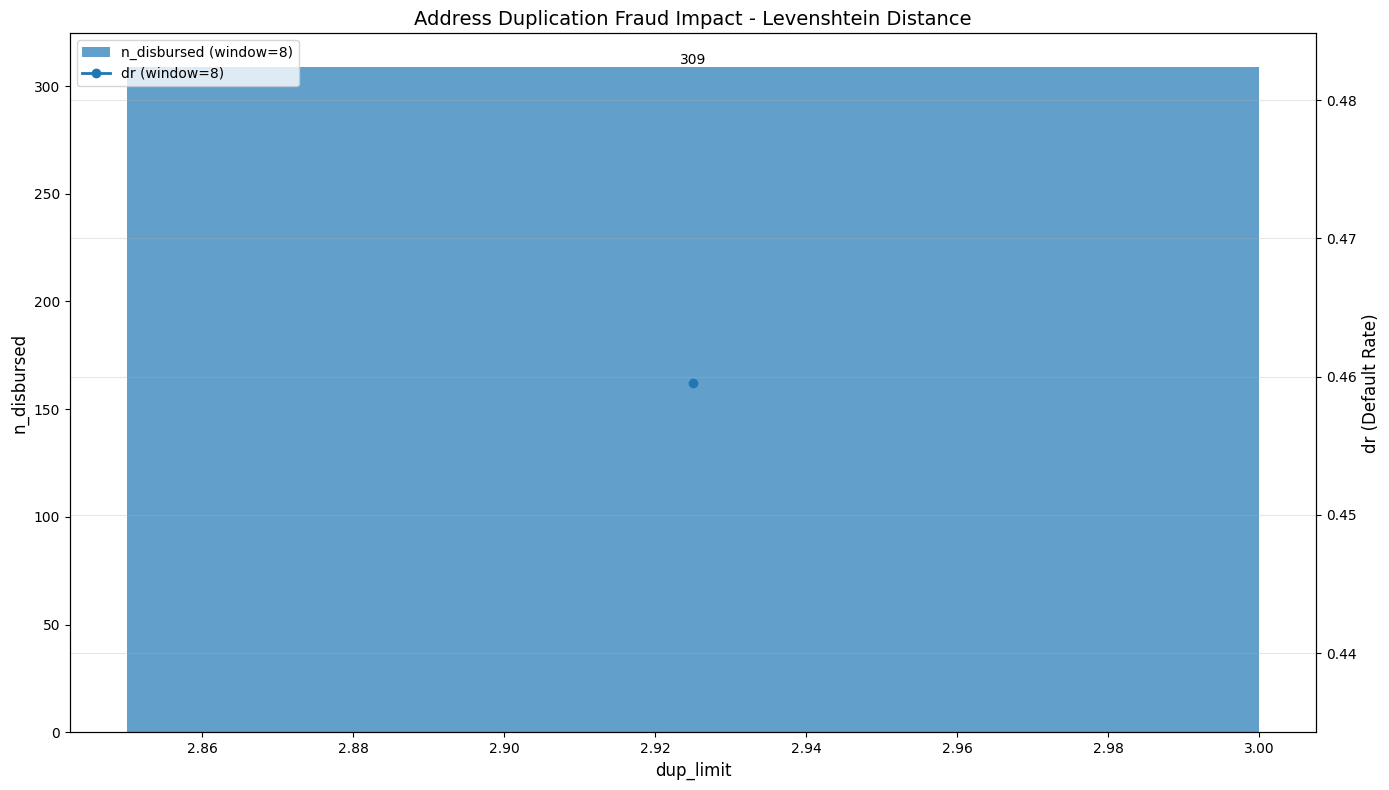

In [4]:
records = []
output = defaultdict(list) 
res = lev_win_distance(df, 8, 3, 0)
res['dup_limit'] = 3  
output['dup_limit'] = 3
output['window'] = 8
output['sim_threshold'] =1
output['n_surveys'] = res['CLIENT_ID'].count()
output['n_disbursed'] = res['DISBURSED'].sum()
output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
records.append(output)
address_dup_fraud = res.copy()

output2 = pd.DataFrame(records)
add_multi_chart(output2, 'Address Duplication Fraud Impact - Levenshtein Distance', 'dup_limit', 'window')

In [5]:
address_dup_fraud

,CLIENT_ID,SURVEY_DATE,FIRST_FIDO_SCORE,FRAUD_TYPE_MATCHED,BUSINESS_RULE_DECISION,HASH,ADDRESS,ADDRESS2,INDUSTRY,POSITION,...,DEFAULTED,PTFRAUD,FRAUD_TYPE,SIMILAR_PRIOR_ADDRESS,SIMILAR_ADDRESSES_COUNT,ADDRESS_DISTANCE,IS_WHITELISTED,DAYS_SINCE_LAST,DEFAULT_RATE,dup_limit
0,560471341,2024-11-18 10:42:26,303.0,NaN,REJECTED,ebyez,Palace garden,NaN,Industry/Manufacturing,sales boy,...,0,0,MULTIPLE_ADDRESS_DUPLICATIONS,Palace Garden,4,0,False,0,0.0,3
1,776946950,2024-10-20 10:24:01,321.0,NaN,APPROVED,ebyh8,AHOBRE 1,NaN,Education,TEACHER,...,0,1,MULTIPLE_ADDRESS_DUPLICATIONS,AHOBRE 1,4,0,False,0,1.0,3
2,668084800,2024-10-20 10:53:18,276.0,NaN,APPROVED,ebyh8,AHOBRE 1,NaN,Education,TEACHER,...,0,0,SIMILAR_TO_BLOCKED,AHOBRE 1,1,0,False,0,0.0,3
3,173321444,2024-11-14 08:24:38,303.0,NaN,REJECTED,ebysp,Near chief palace,NaN,Mining,Im the bulldozer driver,...,0,1,MULTIPLE_ADDRESS_DUPLICATIONS,near chief palace,4,0,False,1,1.0,3
4,55992356,2024-01-08 12:08:35,321.0,NaN,APPROVED,ebytc,TB 74 Teberebe,NaN,Trade - Retail,I sell second hand clothes,...,0,1,MULTIPLE_ADDRESS_DUPLICATIONS,TB 74 Teberebe,4,0,False,2,1.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,828691554,2024-09-12 09:18:41,226.0,NaN,APPROVED,s126f,Pentecost Church,NaN,Education,teacher,...,0,1,SIMILAR_TO_BLOCKED,Pentecost Church,1,0,False,5,1.0,3
346,72434140,2024-09-12 15:45:50,226.0,NaN,APPROVED,s126f,Pentecost Church,NaN,Education,Teacher,...,0,1,SIMILAR_TO_BLOCKED,Pentecost Church,1,0,False,0,1.0,3
347,857239311,2024-01-14 17:03:25,315.0,NaN,REJECTED,s181k,near chief palace,NaN,Education,Im teaching,...,0,0,SIMILAR_TO_BLOCKED,Near Chief palace,1,0,False,2,0.0,3
348,503659864,2024-04-04 06:55:43,256.0,NaN,APPROVED,s1842,Pentecost church,NaN,Security,Immigration officer,...,0,0,SIMILAR_TO_BLOCKED,Pentecost Church,1,0,False,-162,0.0,3


In [6]:
# Assuming fraud_df is your fraud detection results
monthly_stats = calculate_monthly_blocks(address_dup_fraud)

# View the results
print(monthly_stats)

   YEAR_MONTH                     FRAUD_TYPE  BLOCKED_COUNT  DISBURSED_AMOUNT
0     2024-01  MULTIPLE_ADDRESS_DUPLICATIONS              3                 3
1     2024-01             SIMILAR_TO_BLOCKED             60                50
0     2024-01                          TOTAL             63                53
2     2024-02  MULTIPLE_ADDRESS_DUPLICATIONS              3                 3
3     2024-02             SIMILAR_TO_BLOCKED             22                15
1     2024-02                          TOTAL             25                18
4     2024-03             SIMILAR_TO_BLOCKED             11                11
2     2024-03                          TOTAL             11                11
5     2024-04  MULTIPLE_ADDRESS_DUPLICATIONS              2                 1
6     2024-04             SIMILAR_TO_BLOCKED             14                12
3     2024-04                          TOTAL             16                13
7     2024-05  MULTIPLE_ADDRESS_DUPLICATIONS              3     

In [7]:
monthly_avg = monthly_stats[monthly_stats['FRAUD_TYPE'] == 'TOTAL']['BLOCKED_COUNT'].mean()

In [8]:
monthly_avg

np.float64(21.875)

In [9]:
monthly_summary = monthly_stats[monthly_stats['FRAUD_TYPE'] == 'TOTAL']['BLOCKED_COUNT'].agg(['mean', 'median', 'max', 'min']).round(2).to_frame('Monthly Blocks').T

In [10]:
monthly_summary

,mean,median,max,min
Monthly Blocks,21.88,18.0,63.0,7.0
